# Capítulo 4 — Simulación del Dataset de Firmas ILP
## Script 2: Dataset con 13 variables y variable respuesta
### TFG: Diseño de metodologías estadísticas y modelos de ML para verificación de firmas en ILP
---
**Estructura del notebook:**
1. Librerías y parámetros globales
2. Simulación del dataset (versión 10% y 20% de inválidas)
3. Análisis exploratorio (EDA)
4. Correlaciones y distribuciones por clase
5. Exportación del dataset a CSV

---
**Variables simuladas (según Capítulo 3, Sección 3.1.1):**

| Bloque | Variable | Descripción |
|--------|----------|-------------|
| 1 | x1 | Coincidencia DNI con censo y nombre/apellidos |
| 1 | x2 | Edad dentro del rango electoral (16-100) |
| 1 | x3 | Coherencia municipio declarado vs censal |
| 1 | x4 | Vigencia del DNI en la fecha de firma |
| 2 | x5 | Nº apariciones del DNI en el conjunto de pliegos |
| 2 | x6 | Nº apariciones del DNI en el mismo pliego |
| 2 | x7 | Distancia Levenshtein nombre declarado vs censal |
| 2 | x8 | Coincidencias nombre+fecha nacimiento con DNI distinto |
| 3 | x9 | Nº campos obligatorios incompletos |
| 3 | x10 | Firma fuera del periodo oficial de recogida |
| 4 | x11 | Proporción de incidencias en el pliego |
| 4 | x12 | Concentración temporal de firmas en el pliego |
| 4 | x13 | Nº firmas con campos incompletos en el mismo pliego |

**Variable respuesta:** `y = 0` (firma válida) / `y = 1` (firma inválida)


## 1. Librerías y parámetros globales

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'font.family': 'serif'
})

#Parámetros globales 
N_FIRMAS   = 50_000 # Total de firmas simuladas
P_INV_10   = 0.10   # Proporción de inválidas — escenario realista
P_INV_20   = 0.20   # Proporción de inválidas — escenario pesimista

#Datos reales provincias CyL (censo 2025, Junta CyL)
PROVINCIAS  = ['Avila','Burgos','Leon','Palencia','Salamanca',
               'Segovia','Soria','Valladolid','Zamora']
PESOS_PROV  = np.array([159887,361556,446771,158687,328779,
                         158470,90234,528841,165275], dtype=float)
PESOS_PROV /= PESOS_PROV.sum()

N_MUNICIPIOS = 2248          # Municipios de CyL
N_PLIEGOS    = 3000          # Pliegos simulados
N_FEDATARIOS = 500           # Fedatarios/responsables simulados

print("Configuración del dataset:")
print(f"  Firmas totales         : {N_FIRMAS:,}")
print(f"  Escenario 10%%          : {int(N_FIRMAS*P_INV_10):,} inválidas")
print(f"  Escenario 20%%          : {int(N_FIRMAS*P_INV_20):,} inválidas")
print(f"  Variables predictoras  : 13")
print(f"  Provincias             : {len(PROVINCIAS)}")


Configuración del dataset:
  Firmas totales         : 50,000
  Escenario 10%%          : 5,000 inválidas
  Escenario 20%%          : 10,000 inválidas
  Variables predictoras  : 13
  Provincias             : 9


## 2. Simulación del dataset

### Lógica de simulación

El dataset se genera en dos pasos:

1. **Asignación de contexto:** a cada firma se le asigna provincia, municipio,
   pliego y fedatario. Esto permite simular las variables de bloque 4 de forma
   coherente (todas las firmas del mismo pliego comparten concentración temporal
   e incidencias del pliego).

2. **Generación de variables por clase:** las firmas inválidas tienen
   distribuciones desplazadas respecto a las válidas en cada variable,
   reflejando que los indicadores de irregularidad son más frecuentes en
   firmas inválidas. La separación entre clases es intencionalmente imperfecta
   para que los modelos del Capítulo 3 tengan un problema no trivial.


In [ ]:
def simular_dataset(n_firmas, p_invalidas, semilla=2024):
    """
    Genera el dataset de firmas ILP con 13 variables y variable respuesta.

    Parámetros
    ----------
    n_firmas    : número total de firmas
    p_invalidas : proporción de firmas inválidas (y=1)
    semilla     : semilla aleatoria para reproducibilidad

    Retorna
    -------
    df : DataFrame con 13 variables predictoras + variable respuesta y
    """
    rng = np.random.default_rng(semilla)
    n_inv  = int(n_firmas * p_invalidas)
    n_val  = n_firmas - n_inv
    y      = np.array([0]*n_val + [1]*n_inv)   # 0=válida, 1=inválida

    #Contexto estructural
    provincias_idx = rng.choice(len(PROVINCIAS), size=n_firmas, p=PESOS_PROV)
    municipios_idx = rng.integers(0, N_MUNICIPIOS, size=n_firmas)
    pliegos_idx    = rng.integers(0, N_PLIEGOS,    size=n_firmas)
    fedatarios_idx = rng.integers(0, N_FEDATARIOS, size=n_firmas)

    #Proporciones de incidencia por pliego y fedatario
    #(algunos pliegos/fedatarios son sistemáticamente peores)
    incid_pliego    = rng.beta(1.5, 12, size=N_PLIEGOS)   # media ~0.11
    incid_fedatario = rng.beta(1.2, 10, size=N_FEDATARIOS)
    #Pliegos "problemáticos" (10% de pliegos con alta incidencia)
    pliegos_malos = rng.choice(N_PLIEGOS,
                               size=int(N_PLIEGOS*0.10), replace=False)
    incid_pliego[pliegos_malos] = rng.beta(5, 3, size=len(pliegos_malos))

    #Concentración temporal por pliego (días entre primera y última firma)
    conc_temporal = rng.gamma(2, 2, size=N_PLIEGOS)  # media ~4 días
    #Pliegos acelerados (completados en 1 día)
    conc_temporal[pliegos_malos] = rng.uniform(0, 0.5, size=len(pliegos_malos))

    #Campos incompletos por pliego
    campos_inc_pliego = rng.poisson(0.8, size=N_PLIEGOS)
    campos_inc_pliego[pliegos_malos] += rng.poisson(3, size=len(pliegos_malos))

    #Bloque 1: Validación censal e identitaria
    #x1: coincidencia DNI con censo y nombre/apellidos (binaria)
    #Válidas: 97% coinciden | Inválidas: 60% coinciden
    x1 = np.where(y == 0,
                  rng.binomial(1, 0.97, n_firmas),
                  rng.binomial(1, 0.60, n_firmas)).astype(int)

    #x2: edad dentro del rango electoral 18-100 (binaria)
    #Válidas: 99% | Inválidas: 88%
    x2 = np.where(y == 0,
                  rng.binomial(1, 0.99, n_firmas),
                  rng.binomial(1, 0.88, n_firmas)).astype(int)

    #x3: coherencia municipio declarado vs censal (binaria)
    #Válidas: 96% | Inválidas: 65%
    x3 = np.where(y == 0,
                  rng.binomial(1, 0.96, n_firmas),
                  rng.binomial(1, 0.65, n_firmas)).astype(int)

    #x4: vigencia DNI en fecha de firma (binaria)
    #Válidas: 98% | Inválidas: 80%
    x4 = np.where(y == 0,
                  rng.binomial(1, 0.98, n_firmas),
                  rng.binomial(1, 0.80, n_firmas)).astype(int)

    #Bloque 2: Detección de duplicados
    #x5: nº apariciones del DNI en el conjunto de pliegos
    #Válidas: Poisson(1.05) | Inválidas: Poisson(2.1)
    x5_val = rng.poisson(1.05, n_firmas)
    x5_inv = rng.poisson(2.10, n_firmas)
    x5     = np.where(y == 0, x5_val, x5_inv).clip(1, 20)

    #x6: nº apariciones del DNI en el mismo pliego
    #Válidas: casi siempre 1 | Inválidas: puede ser >1
    x6_val = rng.choice([1,1,1,1,1,2], size=n_firmas)
    x6_inv = rng.choice([1,1,2,2,3,4], size=n_firmas)
    x6     = np.where(y == 0, x6_val, x6_inv).clip(1, 10)

    #x7: distancia Levenshtein nombre declarado vs censal
    #Válidas: mayormente 0 | Inválidas: distribución más dispersa
    x7_val = rng.choice([0,0,0,0,0,1,1,2], size=n_firmas)
    x7_inv = rng.choice([0,0,1,1,2,2,3,4,5], size=n_firmas)
    x7     = np.where(y == 0, x7_val, x7_inv).clip(0, 10)

    #x8: coincidencias nombre+fecha_nacimiento con DNI distinto
    #Válidas: casi 0 | Inválidas: ocasionalmente >0
    x8_val = rng.binomial(1, 0.02, n_firmas)
    x8_inv = rng.binomial(1, 0.18, n_firmas)
    x8     = np.where(y == 0, x8_val, x8_inv).astype(int)

    #Bloque 3: Integridad documental
    #x9: nº campos obligatorios incompletos (0-5)
    #Válidas: Poisson(0.15) | Inválidas: Poisson(1.2)
    x9_val = rng.poisson(0.15, n_firmas)
    x9_inv = rng.poisson(1.20, n_firmas)
    x9     = np.where(y == 0, x9_val, x9_inv).clip(0, 5)

    #x10: firma fuera del periodo oficial (binaria)
    #Válidas: 1% | Inválidas: 20%
    x10 = np.where(y == 0,
                   rng.binomial(1, 0.01, n_firmas),
                   rng.binomial(1, 0.20, n_firmas)).astype(int)

    #Bloque 4: Patrones estadísticos agregados
    #x11: proporción de incidencias en el pliego al que pertenece la firma
    x11 = incid_pliego[pliegos_idx]
    #Añadir ruido individual
    x11 = np.clip(x11 + rng.normal(0, 0.02, n_firmas), 0, 1)

    #x12: concentración temporal (valor bajo = acelerado = sospechoso)
    x12 = conc_temporal[pliegos_idx]
    x12 = np.clip(x12 + rng.normal(0, 0.3, n_firmas), 0, None)

    #x13: nº firmas con campos incompletos en el mismo pliego
    x13 = campos_inc_pliego[pliegos_idx]
    x13 = np.clip(x13 + rng.poisson(0.2, n_firmas), 0, 30).astype(int)

    #Unión de las variables para generar el DataFrame
    df = pd.DataFrame({
        'provincia' : [PROVINCIAS[i] for i in provincias_idx],
        'municipio' : municipios_idx,
        'pliego'    : pliegos_idx,
        'fedatario' : fedatarios_idx,
        'x1'  : x1,   'x2'  : x2,   'x3'  : x3,   'x4'  : x4,
        'x5'  : x5,   'x6'  : x6,   'x7'  : x7,   'x8'  : x8,
        'x9'  : x9,   'x10' : x10,
        'x11' : np.round(x11, 4),
        'x12' : np.round(x12, 3),
        'x13' : x13,
        'y'   : y
    })

    # Mezclar aleatoriamente para eliminar el orden válidas/inválidas
    df = df.sample(frac=1, random_state=semilla).reset_index(drop=True)
    df.index.name = 'firma_id'
    return df

#Generar los dos datasets
df_10 = simular_dataset(N_FIRMAS, P_INV_10, semilla=2024)
df_20 = simular_dataset(N_FIRMAS, P_INV_20, semilla=2025)

print("Dataset 10% inválidas:")
print(f"  Shape : {df_10.shape}")
print(f"  Válidas (y=0): {(df_10.y==0).sum():,}  |  Inválidas (y=1): {(df_10.y==1).sum():,}")
print(f"  Prop. inválidas: {df_10.y.mean():.3f}")
print(df_10.head())
print()
print("Dataset 20% inválidas:")
print(f"  Shape : {df_20.shape}")
print(f"  Válidas (y=0): {(df_20.y==0).sum():,}  |  Inválidas (y=1): {(df_20.y==1).sum():,}")
print(f"  Prop. inválidas: {df_20.y.mean():.3f}")



Dataset 10% inválidas:
  Shape : (50000, 18)
  Válidas (y=0): 45,000  |  Inválidas (y=1): 5,000
  Prop. inválidas: 0.100
           provincia  municipio  pliego  fedatario  x1  x2  x3  x4  x5  x6  \
firma_id                                                                     
0         Valladolid        918    2902          8   1   1   1   1   2   1   
1         Valladolid        378     561         72   1   1   1   1   2   1   
2               Leon       1656     629        276   1   1   1   1   1   1   
3             Zamora        981     752         65   1   1   1   1   1   2   
4               Leon         99    2473        359   1   1   1   1   1   1   

          x7  x8  x9  x10     x11     x12  x13  y  
firma_id                                           
0          1   0   1    0  0.1125   4.983    0  0  
1          0   0   0    0  0.0740   0.994    1  0  
2          0   0   0    0  0.0485   3.705    2  0  
3          0   0   0    0  0.0964   6.686    0  0  
4          2   0   0

## 3. Descripción estadística del dataset (A partir de aquí trabajaremos con el dataset de 10% inválidas para hacer los análisis ya que ambos dataset son similares por no repetir los procesos dos veces)

In [6]:
# Trabajamos con el dataset del 10% para el EDA principal
df = df_10.copy()
vars_pred = [f'x{i}' for i in range(1, 14)]

print('********************')
print("  ESTADÍSTICAS DESCRIPTIVAS — VARIABLES PREDICTORAS (df 10%)")
print('********************')
desc = df[vars_pred].describe().T
desc['missing'] = df[vars_pred].isnull().sum()
desc['dtype']   = df[vars_pred].dtypes.astype(str)
print(desc[['count','mean','std','min','25%','50%','75%','max',
            'missing','dtype']].to_string())

print()
print("  Variables binarias (x1-x4, x8, x10):")
for v in ['x1','x2','x3','x4','x8','x10']:
    vc = df[v].value_counts().sort_index()
    print(f"    {v}: {dict(vc)}  (% valor=1: {df[v].mean():.3f})")

print()
print("  Distribución de y (variable respuesta):")
print(df['y'].value_counts().to_string())
print(f"  Ratio desequilibrio: {(df.y==0).sum()/(df.y==1).sum():.1f}:1")


********************
  ESTADÍSTICAS DESCRIPTIVAS — VARIABLES PREDICTORAS (df 10%)
********************
       count      mean       std  min     25%     50%     75%      max  missing    dtype
x1   50000.0  0.931560  0.252502  0.0  1.0000  1.0000  1.0000   1.0000        0    int64
x2   50000.0  0.979200  0.142716  0.0  1.0000  1.0000  1.0000   1.0000        0    int64
x3   50000.0  0.930260  0.254711  0.0  1.0000  1.0000  1.0000   1.0000        0    int64
x4   50000.0  0.961780  0.191729  0.0  1.0000  1.0000  1.0000   1.0000        0    int64
x5   50000.0  1.484260  0.847447  1.0  1.0000  1.0000  2.0000  10.0000        0    int64
x6   50000.0  1.268340  0.572940  1.0  1.0000  1.0000  1.0000   4.0000        0    int64
x7   50000.0  0.648220  0.956833  0.0  0.0000  0.0000  1.0000   5.0000        0    int64
x8   50000.0  0.034300  0.182000  0.0  0.0000  0.0000  0.0000   1.0000        0    int64
x9   50000.0  0.254720  0.593266  0.0  0.0000  0.0000  0.0000   5.0000        0    int64
x10  50

## 4. Análisis exploratorio: distribuciones por clase

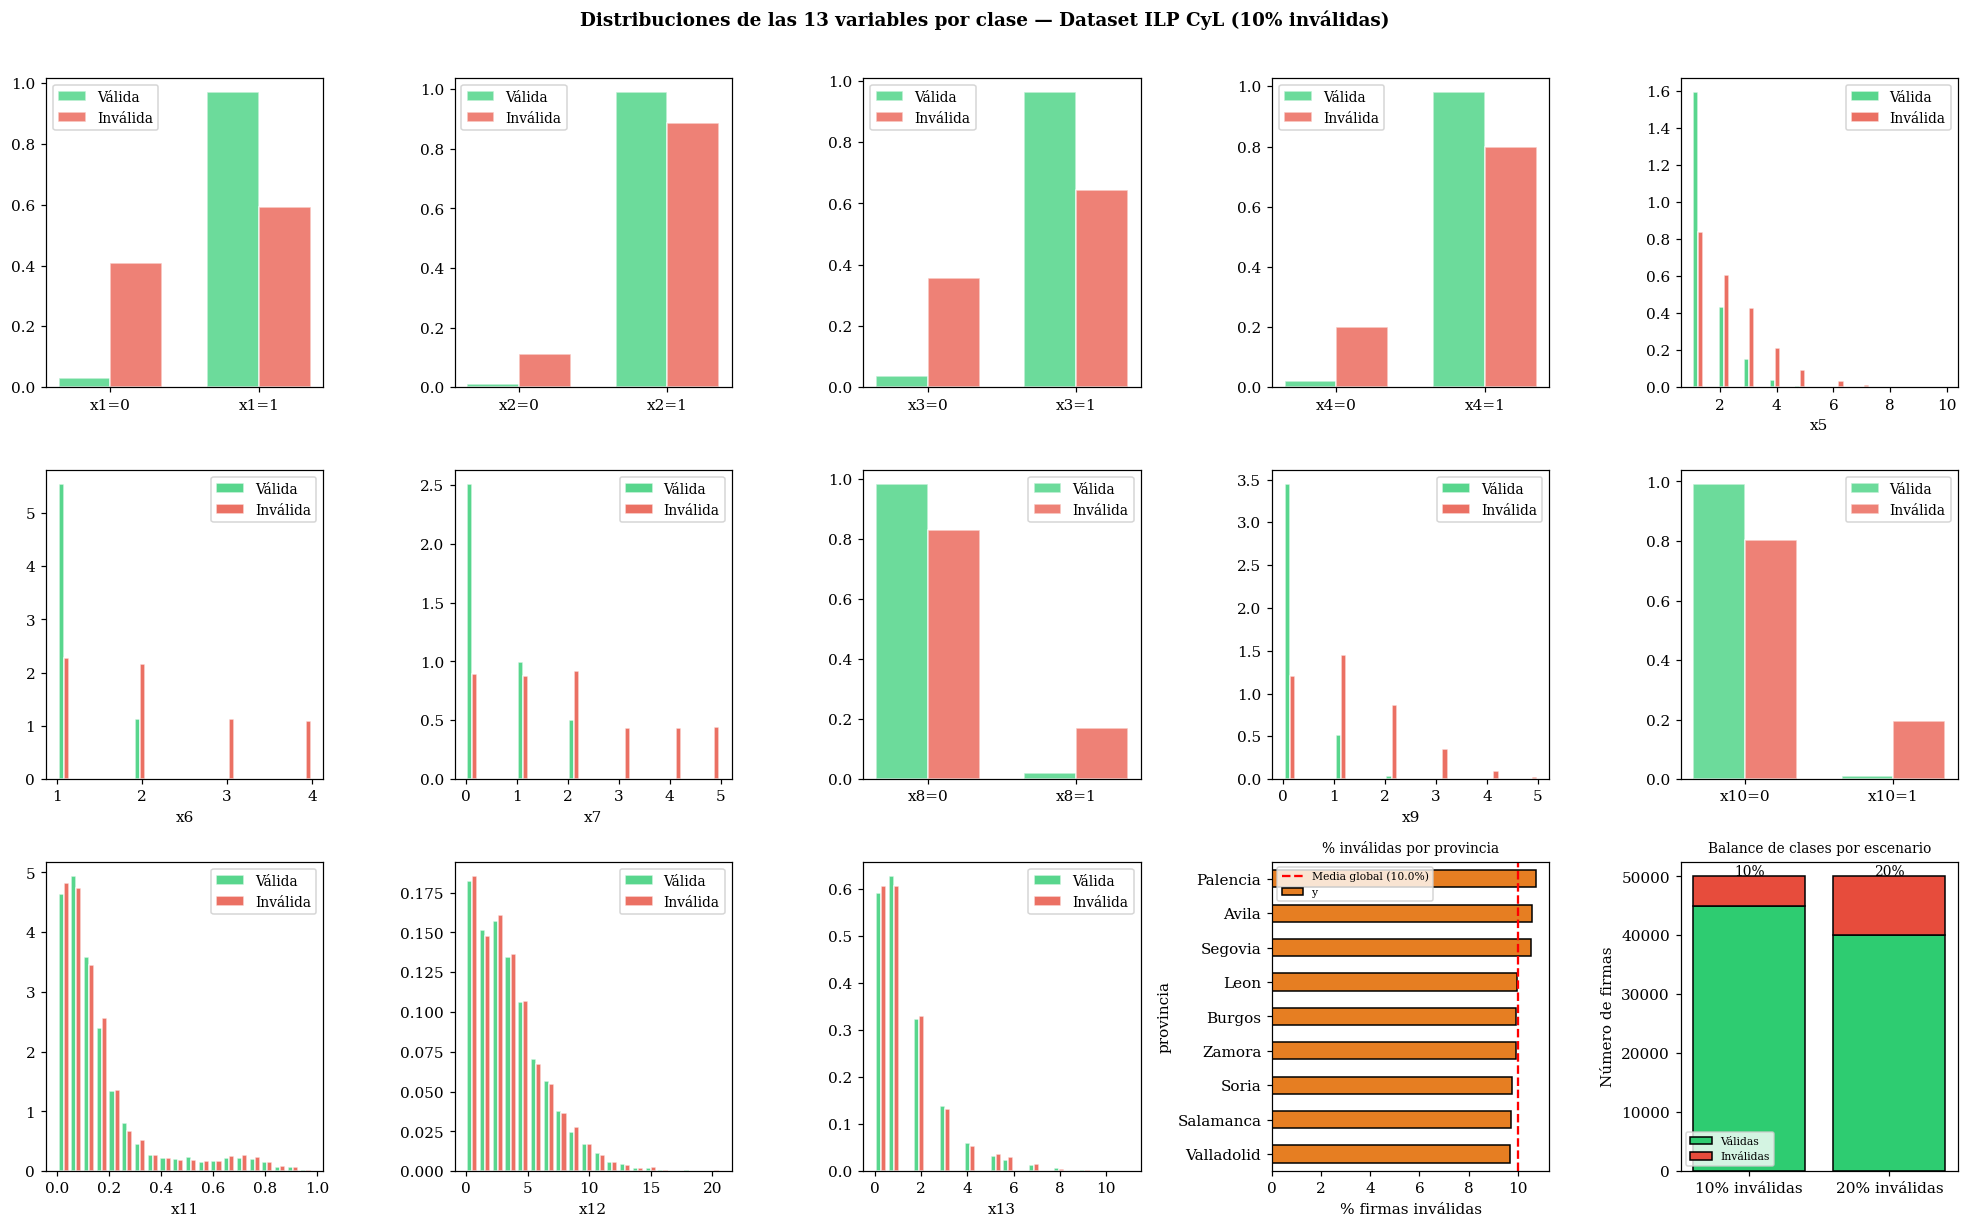

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

colores = {0: '#2ecc71', 1: '#e74c3c'}
etiq    = {0: 'Válida (y=0)', 1: 'Inválida (y=1)'}

vars_desc = {
    'x1' : 'DNI coincide con censo',
    'x2' : 'Edad en rango electoral',
    'x3' : 'Municipio coherente',
    'x4' : 'DNI vigente',
    'x5' : 'Apariciones DNI (pliegos)',
    'x6' : 'Apariciones DNI (pliego)',
    'x7' : 'Distancia Levenshtein',
    'x8' : 'Suplantación detectada',
    'x9' : 'Campos incompletos',
    'x10': 'Fuera de periodo',
    'x11': 'Prop. incidencias pliego',
    'x12': 'Concentración temporal',
    'x13': 'Campos incom. en pliego'
}

binarias = ['x1','x2','x3','x4','x8','x10']

for ax, var in zip(axes[:13], vars_pred):
    if var in binarias:
        vals = [0, 1]
        x_pos = np.arange(len(vals))
        width = 0.35
        for clase, color, label in zip([0,1], ['#2ecc71','#e74c3c'], ['Válida','Inválida']):
            prop_clase = df[df.y == clase][var].value_counts(normalize=True).sort_index()
            prop = [prop_clase.get(v, 0) for v in vals]
            ax.bar(x_pos + (width/2 if clase==1 else -width/2), prop, width,
                   color=color, label=label, alpha=0.7, edgecolor='white')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'{var}=0', f'{var}=1'])
        ax.legend()
    else:
        bins = np.histogram_bin_edges(df[var], bins=20)
        hist_val, _ = np.histogram(df[df.y==0][var], bins=bins, density=True)
        hist_inv, _ = np.histogram(df[df.y==1][var], bins=bins, density=True)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        width = (bins[1] - bins[0]) * 0.4   
        ax.bar(bin_centers - width/2, hist_val, width=width,
            color=colores[0], label='Válida', alpha=0.8, edgecolor='white')
        ax.bar(bin_centers + width/2, hist_inv, width=width,
            color=colores[1], label='Inválida', alpha=0.8, edgecolor='white')
        ax.legend()
        ax.set_xlabel(var)
        
#Subplot 14: % inválidas por provincia
ax = axes[13]
prov_invalidas = (df.groupby('provincia')['y'].mean() * 100).sort_values()
prov_invalidas.plot(kind='barh', ax=ax, color='#e67e22', edgecolor='black')
ax.axvline(df.y.mean()*100, color='red', linestyle='--', linewidth=1.5,
           label=f'Media global ({df.y.mean()*100:.1f}%)')
ax.set_title('% inválidas por provincia', fontsize=9)
ax.set_xlabel('% firmas inválidas')
ax.legend(fontsize=7)

#Subplot 15: balance de clases 10% vs 20%
ax = axes[14]
escenarios = ['10% inválidas', '20% inválidas']
n_val_s  = [(df_10.y==0).sum(), (df_20.y==0).sum()]
n_inv_s  = [(df_10.y==1).sum(), (df_20.y==1).sum()]
x_pos = np.arange(2)
ax.bar(x_pos, n_val_s, label='Válidas', color='#2ecc71', edgecolor='black')
ax.bar(x_pos, n_inv_s, bottom=n_val_s,
       label='Inválidas', color='#e74c3c', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(escenarios)
ax.set_title('Balance de clases por escenario', fontsize=9)
ax.set_ylabel('Número de firmas')
ax.legend(fontsize=7)
for i, (v, inv) in enumerate(zip(n_val_s, n_inv_s)):
    ax.text(i, v + inv + 200, f'{inv/(v+inv):.0%}', ha='center', fontsize=9)

plt.suptitle('Distribuciones de las 13 variables por clase — Dataset ILP CyL (10% inválidas)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlaciones y separabilidad entre clases

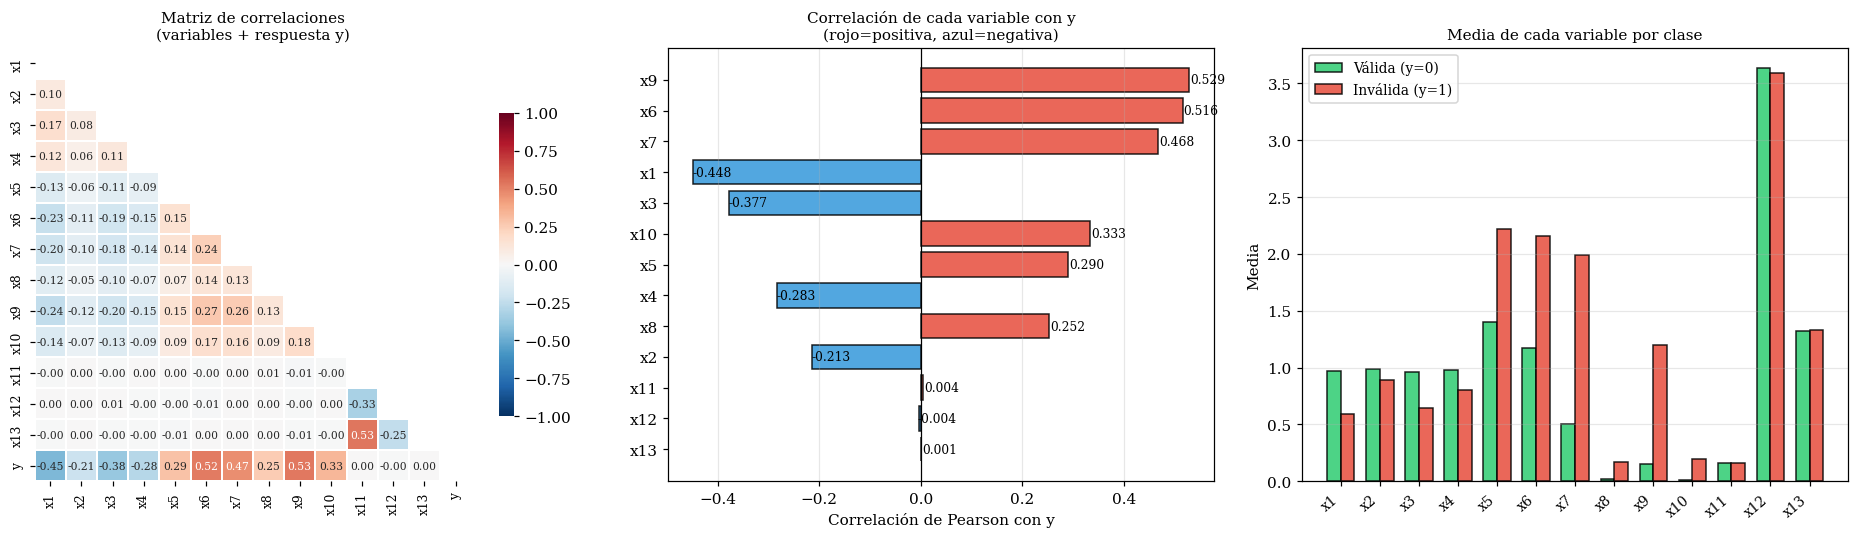


Medias por clase:
     Válida (y=0)  Inválida (y=1)
x1         0.9692          0.5924
x2         0.9894          0.8878
x3         0.9623          0.6422
x4         0.9798          0.7992
x5         1.4022          2.2226
x6         1.1699          2.1546
x7         0.4991          1.9906
x8         0.0190          0.1720
x9         0.1501          1.1964
x10        0.0100          0.1952
x11        0.1618          0.1643
x12        3.6320          3.5947
x13        1.3204          1.3268


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

#Mapa de correlaciones
corr_matrix = df[vars_pred + ['y']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask,
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7}, linewidths=0.3,
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Matriz de correlaciones\n(variables + respuesta y)', fontsize=10)
axes[0].tick_params(labelsize=8)

#Correlación de cada variable con y
corr_con_y = df[vars_pred + ['y']].corr()['y'].drop('y').sort_values(key=abs,
                                                                      ascending=True)
colores_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_con_y]
axes[1].barh(corr_con_y.index, corr_con_y.values,
             color=colores_corr, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de cada variable con y\n(rojo=positiva, azul=negativa)',
                  fontsize=10)
axes[1].set_xlabel('Correlación de Pearson con y')
for i, (v, c) in enumerate(zip(corr_con_y.values, corr_con_y.index)):
    axes[1].text(v + 0.002 * np.sign(v), i, f'{v:.3f}',
                 va='center', fontsize=8)
axes[1].grid(True, alpha=0.3, axis='x')

#Medias por clase (perfil de firma inválida)
medias = df.groupby('y')[vars_pred].mean().T
medias.columns = ['Válida (y=0)', 'Inválida (y=1)']
x_pos = np.arange(len(vars_pred))
w = 0.35
axes[2].bar(x_pos - w/2, medias['Válida (y=0)'],   w,
            label='Válida (y=0)',   color='#2ecc71', edgecolor='black', alpha=0.85)
axes[2].bar(x_pos + w/2, medias['Inválida (y=1)'], w,
            label='Inválida (y=1)', color='#e74c3c', edgecolor='black', alpha=0.85)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(vars_pred, rotation=40, ha='right', fontsize=9)
axes[2].set_title('Media de cada variable por clase', fontsize=10)
axes[2].set_ylabel('Media')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabla de medias por clase
print("\nMedias por clase:")
print(medias.round(4).to_string())


## 6. Test de significatividad por variable (binaria y no binaria) para cada una se usa un estadístico diferente

In [15]:
from scipy.stats import mannwhitneyu, chi2_contingency

print("=" * 65)
print("  TEST DE SEPARABILIDAD ENTRE CLASES POR VARIABLE")
print("  (Mann-Whitney U para continuas/discretas, Chi2 para binarias)")
print("=" * 65)
print(f"{'Variable':<8} {'Media válidas':>14} {'Media inválidas':>16} "
      f"{'Test':>6} {'p-valor':>10} {'Significativa':>14}")
print("-" * 65)

resultados_sep = []
for var in vars_pred:
    val_data = df[df.y==0][var]
    inv_data = df[df.y==1][var]
    m_val = val_data.mean()
    m_inv = inv_data.mean()

    if var in binarias:
        tabla = pd.crosstab(df[var], df['y'])
        _, p, _, _ = chi2_contingency(tabla)
        test_nm = 'Chi2'
    else:
        _, p = mannwhitneyu(val_data, inv_data, alternative='two-sided')
        test_nm = 'MWU'

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'NS'))
    resultados_sep.append({'variable':var, 'm_val':m_val, 'm_inv':m_inv,
                            'p_valor':p, 'test':test_nm, 'sig':sig})
    print(f"{var:<8} {m_val:>14.4f} {m_inv:>16.4f} "
          f"{test_nm:>6} {p:>10.2e} {sig:>14}")

print("-" * 65)
n_sig = sum(1 for r in resultados_sep if r['sig'] != 'NS')
print(f"  Variables con diferencias significativas (p<0.05): {n_sig}/13")


  TEST DE SEPARABILIDAD ENTRE CLASES POR VARIABLE
  (Mann-Whitney U para continuas/discretas, Chi2 para binarias)
Variable  Media válidas  Media inválidas   Test    p-valor  Significativa
-----------------------------------------------------------------
x1               0.9692           0.5924   Chi2   0.00e+00            ***
x2               0.9894           0.8878   Chi2   0.00e+00            ***
x3               0.9623           0.6422   Chi2   0.00e+00            ***
x4               0.9798           0.7992   Chi2   0.00e+00            ***
x5               1.4022           2.2226    MWU   0.00e+00            ***
x6               1.1699           2.1546    MWU   0.00e+00            ***
x7               0.4991           1.9906    MWU   0.00e+00            ***
x8               0.0190           0.1720   Chi2   0.00e+00            ***
x9               0.1501           1.1964    MWU   0.00e+00            ***
x10              0.0100           0.1952   Chi2   0.00e+00            ***
x11   

## 7. Verificación de coherencia del dataset

In [17]:
print("=" * 60)
print("  VERIFICACIÓN DE COHERENCIA DEL DATASET")
print("=" * 60)

checks = []

# Check 1: proporción de inválidas
p_inv_real_10 = df_10.y.mean()
p_inv_real_20 = df_20.y.mean()
checks.append(('Prop. inválidas 10%', p_inv_real_10,
               abs(p_inv_real_10-0.10)<0.005))
checks.append(('Prop. inválidas 20%', p_inv_real_20,
               abs(p_inv_real_20-0.20)<0.005))

# Check 2: variables binarias en rango [0,1]
for var in binarias:
    ok = df_10[var].isin([0,1]).all()
    checks.append((f'{var} en {{0,1}}', df_10[var].unique().tolist(), ok))

# Check 3: variables no negativas
for var in ['x5','x6','x7','x8','x9','x13']:
    ok = (df_10[var] >= 0).all()
    checks.append((f'{var} >= 0', df_10[var].min(), ok))

# Check 4: x11 en [0,1]
ok = ((df_10['x11'] >= 0) & (df_10['x11'] <= 1)).all()
checks.append(('x11 en [0,1]', f'[{df_10.x11.min():.3f},{df_10.x11.max():.3f}]', ok))

# Check 5: sin valores missing
missing = df_10[vars_pred + ['y']].isnull().sum().sum()
checks.append(('Sin valores missing', missing, missing == 0))

# Check 6: correlación x5 > x6 (DNI aparece más en total que en un pliego)
ok = df_10['x5'].mean() >= df_10['x6'].mean()
checks.append(('Media x5 >= media x6', f'{df_10.x5.mean():.3f}>={df_10.x6.mean():.3f}', ok))

print(f"{'Check':<35} {'Valor':>20} {'OK':>5}")
print("-" * 60)
for nombre, valor, ok in checks:
    estado = '  ✓' if ok else '  ✗'
    print(f"{nombre:<35} {str(valor):>20} {estado:>5}")

n_ok = sum(1 for _, _, ok in checks if ok)
print("-" * 60)
print(f"  Checks superados: {n_ok}/{len(checks)}")


  VERIFICACIÓN DE COHERENCIA DEL DATASET
Check                                              Valor    OK
------------------------------------------------------------
Prop. inválidas 10%                                  0.1     ✓
Prop. inválidas 20%                                  0.2     ✓
x1 en {0,1}                                       [1, 0]     ✓
x2 en {0,1}                                       [1, 0]     ✓
x3 en {0,1}                                       [1, 0]     ✓
x4 en {0,1}                                       [1, 0]     ✓
x8 en {0,1}                                       [0, 1]     ✓
x10 en {0,1}                                      [0, 1]     ✓
x5 >= 0                                                1     ✓
x6 >= 0                                                1     ✓
x7 >= 0                                                0     ✓
x8 >= 0                                                0     ✓
x9 >= 0                                                0     ✓
x13 >= 0        

## 8. Exportación del dataset

In [19]:
# Exportar los dos datasets
path_10 = 'dataset_ILP_CyL_10pct.csv'
path_20 = 'dataset_ILP_CyL_20pct.csv'

df_10.to_csv(path_10, index=True)
df_20.to_csv(path_20, index=True)

print(f"Dataset 10% exportado: {path_10}")
print(f"Dataset 20% exportado: {path_20}")



Dataset 10% exportado: dataset_ILP_CyL_10pct.csv
Dataset 20% exportado: dataset_ILP_CyL_20pct.csv
